In [2]:
import sys
sys.path.append('../')
%reload_ext autoreload 
%autoreload 2

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen i

In [3]:
from predictor.classification_class import Classification
from predictor.cross_country_functions import *

c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare the data:

In [4]:
#read the features
data_all = pd.read_csv('../data/eth/eth_features.csv', index_col=0)
data_all.index = data_all.index.astype(str)

-------------------

read the target of interest, e.g., mimi_simple:

In [4]:
#targets can be ['va_ai', 'fol_ai', 'vb12_ai', 'fe_ai', 'zn_ai', 'mimi_simple']
t = 'mimi_simple'

In [5]:
y = target('../data/ethiopia_nigeria_targets.csv', t, survey_id='ETH_2018_ESS_v03_M')

prepare the target for classification:

In [6]:
y = prepare_target_classes(y, t)

In [7]:
y.head()

,mimi_simple
hhid,
010101088800910007,1
010101088800910017,1
010101088800910026,1
010101088800910029,0
010101088800910038,1


### Classification:

!!! take the random state and best hyper-parameters after resampling 5 times:

In [8]:
best_random_state = pd.read_csv('../data/results/perf_%s_ETH_undersampling_3.2_xgboost.csv'%t).best_random_state[0]

In [9]:
classification = Classification(y, data_all, type_target=t, random_state=best_random_state, sampling='undersampling', sampling_strategy=1)

In [10]:
data_all

,asset1,asset2,asset3,asset6,asset7,asset8,education2,food group1,food group2,food group3,...,housing1,housing2,housing4,labour1,labour2,labour4,labour5,r3q,rfh_avg,vim_avg
household_id,,,,,,,,,,,,,,,,,,,,,
010101088800910007,0.0,0.0,0.0,0.0,0.0,0.0,1.50,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910017,0.0,0.0,1.0,0.0,0.0,0.0,2.00,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910026,0.0,0.0,0.0,0.0,0.0,0.0,2.00,1.0,1.0,1.0,...,2.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910029,0.0,0.0,0.0,0.0,0.0,0.0,3.00,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910038,0.0,0.0,1.0,0.0,0.0,0.0,2.00,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150101088803701057,0.0,0.0,0.0,0.0,0.0,0.0,2.05,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405
150101088803701067,0.0,0.0,1.0,0.0,0.0,0.0,2.50,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405
150101088803701077,0.0,0.0,0.0,0.0,0.0,0.0,2.05,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405


In [11]:
classification.data

,mimi_simple,asset1,asset2,asset3,asset6,asset7,asset8,education2,food group1,food group2,...,housing1,housing2,housing4,labour1,labour2,labour4,labour5,r3q,rfh_avg,vim_avg
hhid,,,,,,,,,,,,,,,,,,,,,
010101088800910007,1,0.0,0.0,0.0,0.0,0.0,0.0,1.50,1.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910017,1,0.0,0.0,1.0,0.0,0.0,0.0,2.00,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910026,1,0.0,0.0,0.0,0.0,0.0,0.0,2.00,1.0,1.0,...,2.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910029,0,0.0,0.0,0.0,0.0,0.0,0.0,3.00,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,101.75015,7.53465,0.286
010101088800910038,1,0.0,0.0,1.0,0.0,0.0,0.0,2.00,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.75015,7.53465,0.286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150101088803701057,1,0.0,0.0,0.0,0.0,0.0,0.0,2.05,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405
150101088803701067,1,0.0,0.0,1.0,0.0,0.0,0.0,2.50,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405
150101088803701077,1,0.0,0.0,0.0,0.0,0.0,0.0,2.05,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,101.59300,19.46000,0.405


In [12]:
dummy = classification.dummy_classification()

In [13]:
dummy_pred = classification.predictions(dummy)

In [14]:
dummy_performance_indicators = classification.perf_ind_classification(dummy_pred)

train the model getting the best hyperparameters:

In [15]:
model = classification.xgbclassification_best_model('../data/results/besthyper_%s_ETH_undersampling_3.2_XGBoost.csv'%t)

c:\Users\Andreas\projects\mimi-ml\paper_notebooks\..\classification_class.py:186: Warning: warning from our end: to use this function you first need to reset the random_state parameter of the classification class with the number that gives the best model performance after multiple trainings
  warnings.warn("warning from our end: to use this function you first need to reset the random_state parameter of the classification"


get the predictions:

In [16]:
predictions = classification.predictions(model)

get the performances:

In [17]:
performance_indicators = classification.perf_ind_classification(predictions)

In [18]:
threshold_probability = 0.5

In [19]:
#Generate dictionary for adjusted performance indicators
adjusted_performance_indicators = {}

#probalilities
y_proba = classification.y_proba(model)

#---Performance---
if threshold_probability != None:
    predictions = predictions_proba(y_proba, threshold_probability)
else:
    predictions = classification.predictions(model)

array_precision, array_recall, average_pre_recall = calculates_precision_recall_auc(y_proba, classification, drop_intermediate=True)
#append average_pre_recall on performance_indicators
performance_indicators['average_pre_recall'] = average_pre_recall
array_fpr, array_tpr, rocauc_score = calculates_roc_auc(y_proba, classification, drop_intermediate=True)
#append roc scores on performance_indicators
performance_indicators['rocauc_score'] = rocauc_score
#calculate adjusted precision-recall and roc values and save them on the adjusted_performance_indicators
adjusted_roc_auc, adjusted_average_pre_recall = get_adjusted_values(classification, rocauc_score, average_pre_recall)
adjusted_performance_indicators['adjusted_rocauc'] = adjusted_roc_auc
adjusted_performance_indicators['adjusted_average_pre_recall'] = adjusted_average_pre_recall

In [25]:
adjusted_performance_indicators

{'adjusted_rocauc': 0.63, 'adjusted_average_pre_recall': 0.67}

### Variable importance:

get the shap values:

In [20]:
shap_values=classification.shap_values(model)

convert code variable names to meaningful variable names by using lsms information:

In [21]:
explanations = pd.read_csv('../data/features_explanations.csv', index_col=0)
dict_all = explanations.set_index('codename')['explanation'].to_dict()

In [22]:
trainset = classification.train_test['X_train']

In [23]:
trainset = replace_features_col_names(trainset, dict_all)

findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.


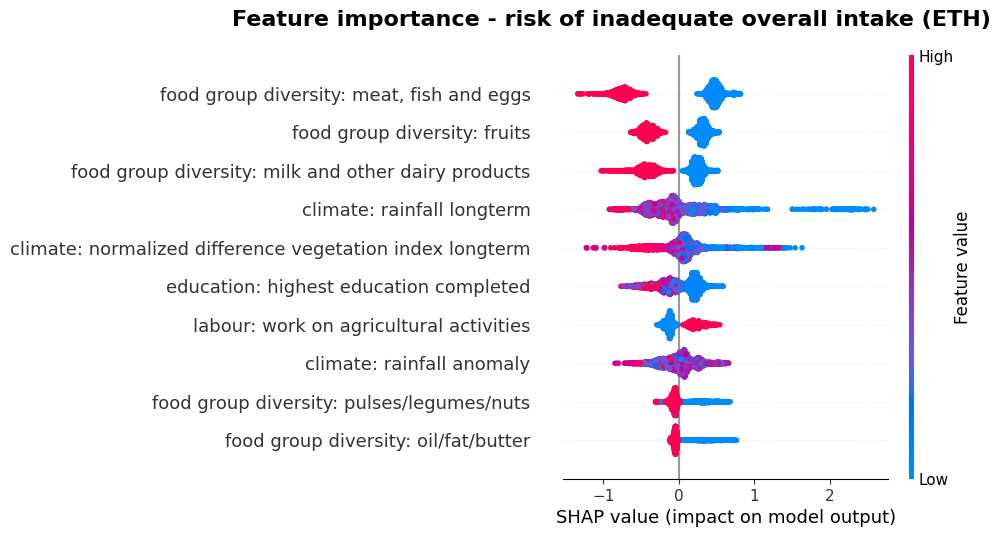

In [24]:
classification.shap_summary_plot(model, trainset, title="Feature importance - risk of inadequate overall intake (ETH)", display=10, iso3='ETH', titlefontsize=16, save=False)
